# EDA — Home Credit Default Risk: `application_train.csv`

## Purpose of this notebook

This is the starting point of **v2** of the `behavioral-default-prediction`
project. Unlike the v1 EDA (a single table, 6 months of history for one
credit card), here we're working with the **main** table of a 5-table
relational dataset.

Before touching the other 4 tables (`bureau.csv`, `previous_application.csv`,
`installments_payments.csv`, `credit_card_balance.csv`), we need to
understand this table on its own:

1. General shape and data types
2. Target balance (`TARGET`)
3. Missing-value landscape — this table is known for having many columns
   with NaN, especially housing-related ones
4. Key financial variables and their relationship with the target
5. Confirm `SK_ID_CURR` is unique per row — this is the key that will
   connect this table to the other 4 later on


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

DATA_PATH = "../data/raw/home_credit/application_train.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 307,511 rows x 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

## 1. Data types and general shape

In [26]:
df.info(verbose=False)
print()
print("Data type counts:")
print(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB

Data type counts:
float64    65
int64      41
object     16
Name: count, dtype: int64


## 2. Confirm `SK_ID_CURR` is a unique key

This is critical: if there are duplicates here, any later `merge` with the
other tables will silently multiply rows — a very common and dangerous bug
when combining relational tables.

In [27]:
n_rows = len(df)
n_unique_ids = df["SK_ID_CURR"].nunique()
print(f"Total rows: {n_rows:,}")
print(f"Unique SK_ID_CURR: {n_unique_ids:,}")
print(f"Is SK_ID_CURR a unique key? {'YES' if n_rows == n_unique_ids else 'NO — DUPLICATES FOUND, investigate before continuing'}")

Total rows: 307,511
Unique SK_ID_CURR: 307,511
Is SK_ID_CURR a unique key? YES


## 3. Target balance (`TARGET`)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


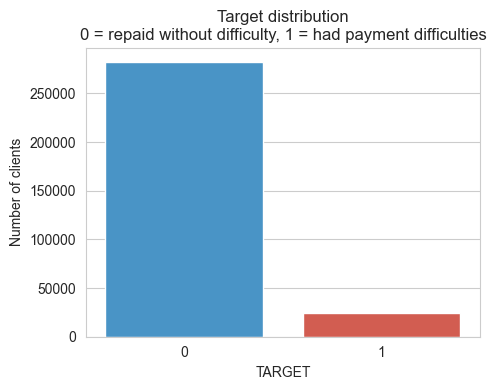

In [28]:
target_counts = df["TARGET"].value_counts(normalize=True) * 100
print(target_counts)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="TARGET", hue="TARGET", palette=["#3498db", "#e74c3c"], legend=False)
plt.title("Target distribution\n0 = repaid without difficulty, 1 = had payment difficulties")
plt.xlabel("TARGET")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

## 4. Missing-value landscape

This table is known for having dozens of columns (mostly the ones starting
with `APARTMENTS_`, `BASEMENTAREA_`, etc. — details about the applicant's
housing) with a very high percentage of NaN. None of this is a data-entry
error: it reflects that not every applicant reports housing details.

In [29]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"Columns with at least one NaN: {len(missing_pct)} out of {df.shape[1]}")
print()
print("Top 20 columns with the most missing values:")
print(missing_pct.head(20))

Columns with at least one NaN: 67 out of 122

Top 20 columns with the most missing values:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64


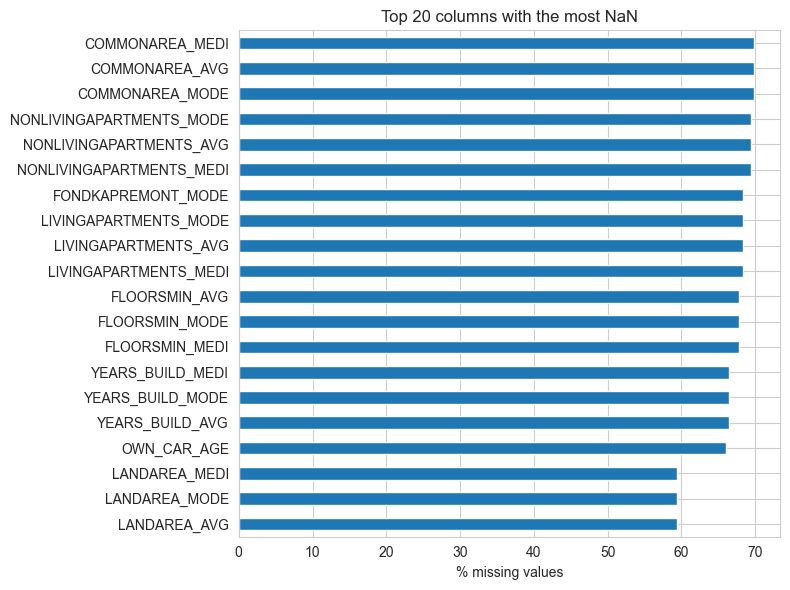

In [30]:
plt.figure(figsize=(8, 6))
missing_pct.head(20)[::-1].plot(kind="barh")
plt.xlabel("% missing values")
plt.title("Top 20 columns with the most NaN")
plt.tight_layout()
plt.show()

## 5. Key financial variables vs. target

A first look at whether the "obvious" financial variables (income, credit
amount, annuity) already show some separation between clients who had
payment difficulties and those who didn't — before building any new
features.

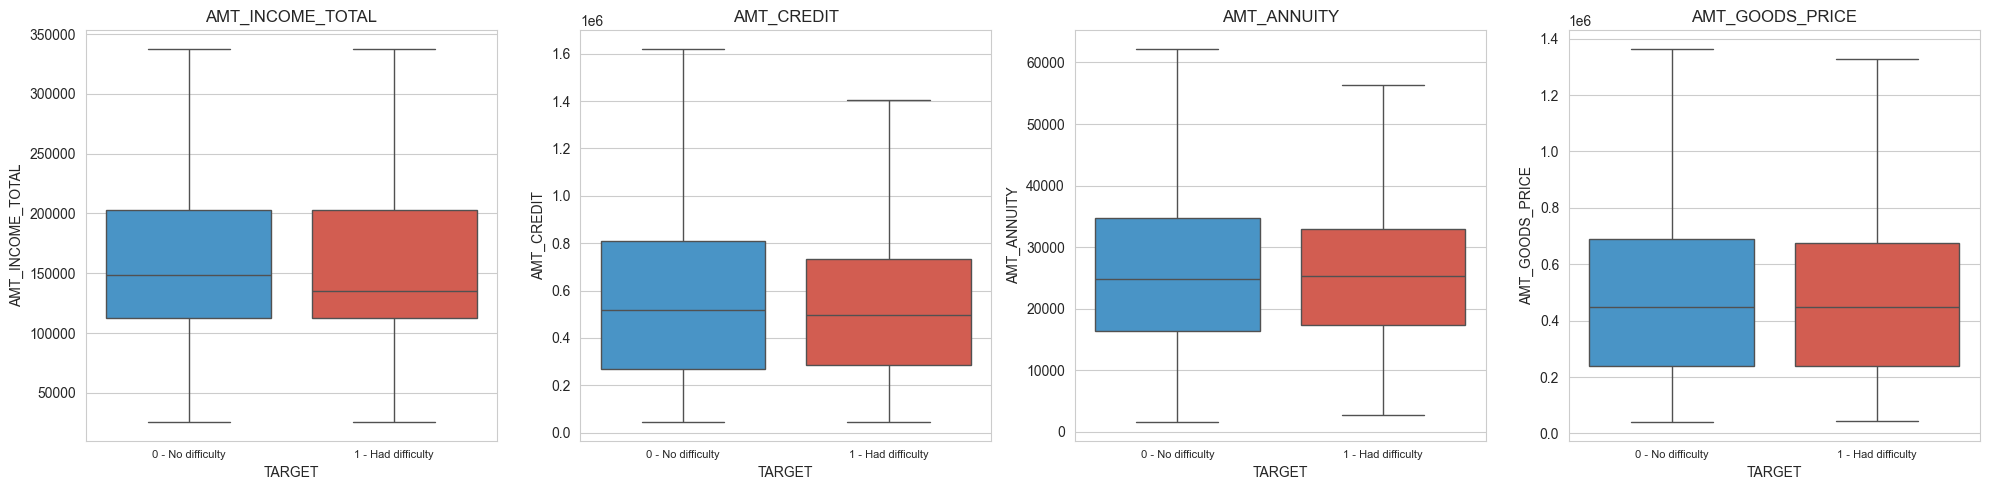

In [31]:
key_financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

fig, axes = plt.subplots(1, len(key_financial_cols), figsize=(20, 5))
for ax, col in zip(axes, key_financial_cols):
    sns.boxplot(data=df, x="TARGET", y=col, hue="TARGET", showfliers=False,
                palette=["#3498db", "#e74c3c"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0 - No difficulty", "1 - Had difficulty"], fontsize=8)
plt.tight_layout()
plt.show()

## 6. Age and employment length

In this dataset, `DAYS_BIRTH` and `DAYS_EMPLOYED` come as NEGATIVE numbers
(days relative to the application date) — they need to be converted into
something readable (years) before interpreting them. `DAYS_EMPLOYED` is also
famous for having a placeholder value of 365243 for unemployed/retired
applicants — this needs to be detected, not treated as a real data point.

Rows with DAYS_EMPLOYED == 365243 (placeholder, not a real value): 55,374 (18.0% of total)


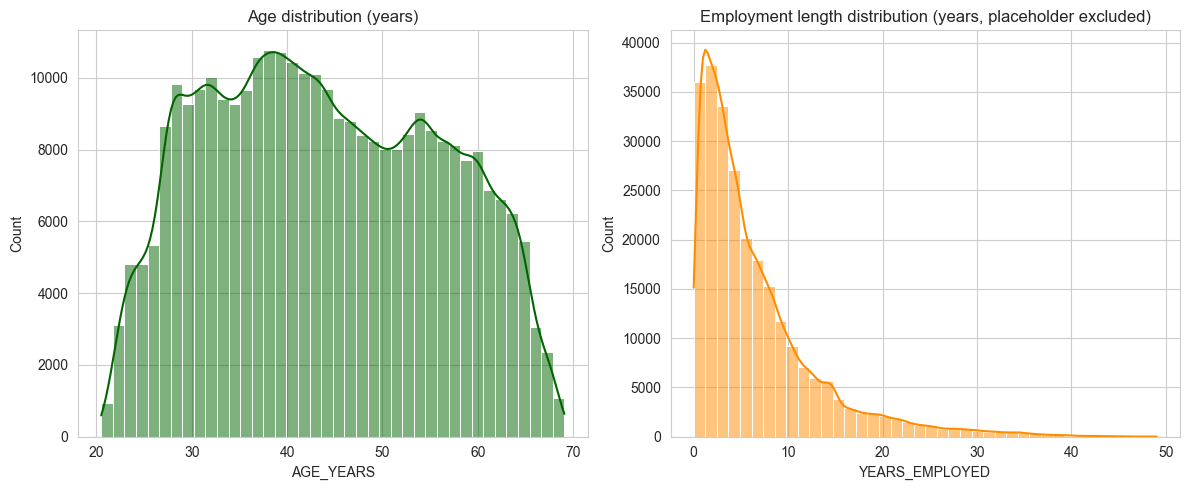

In [32]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

anomaly_value = 365243
n_anomaly = (df["DAYS_EMPLOYED"] == anomaly_value).sum()
print(f"Rows with DAYS_EMPLOYED == {anomaly_value} (placeholder, not a real value): {n_anomaly:,} "
      f"({n_anomaly / len(df) * 100:.1f}% of total)")

df["YEARS_EMPLOYED"] = np.where(
    df["DAYS_EMPLOYED"] == anomaly_value,
    np.nan,
    -df["DAYS_EMPLOYED"] / 365.25
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["AGE_YEARS"], bins=40, kde=True, ax=axes[0], color="darkgreen")
axes[0].set_title("Age distribution (years)")

sns.histplot(df["YEARS_EMPLOYED"].dropna(), bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Employment length distribution (years, placeholder excluded)")
plt.tight_layout()
plt.show()

## 7. Key categorical variables vs. target

A quick, cheap check before moving on to the relational tables: do the
"obvious" categorical variables (education, income type, occupation) show
any visible separation by target? Financial snapshot values showed weak
separation — categorical variables are a different kind of signal and worth
checking before assuming the main table has nothing more to offer.

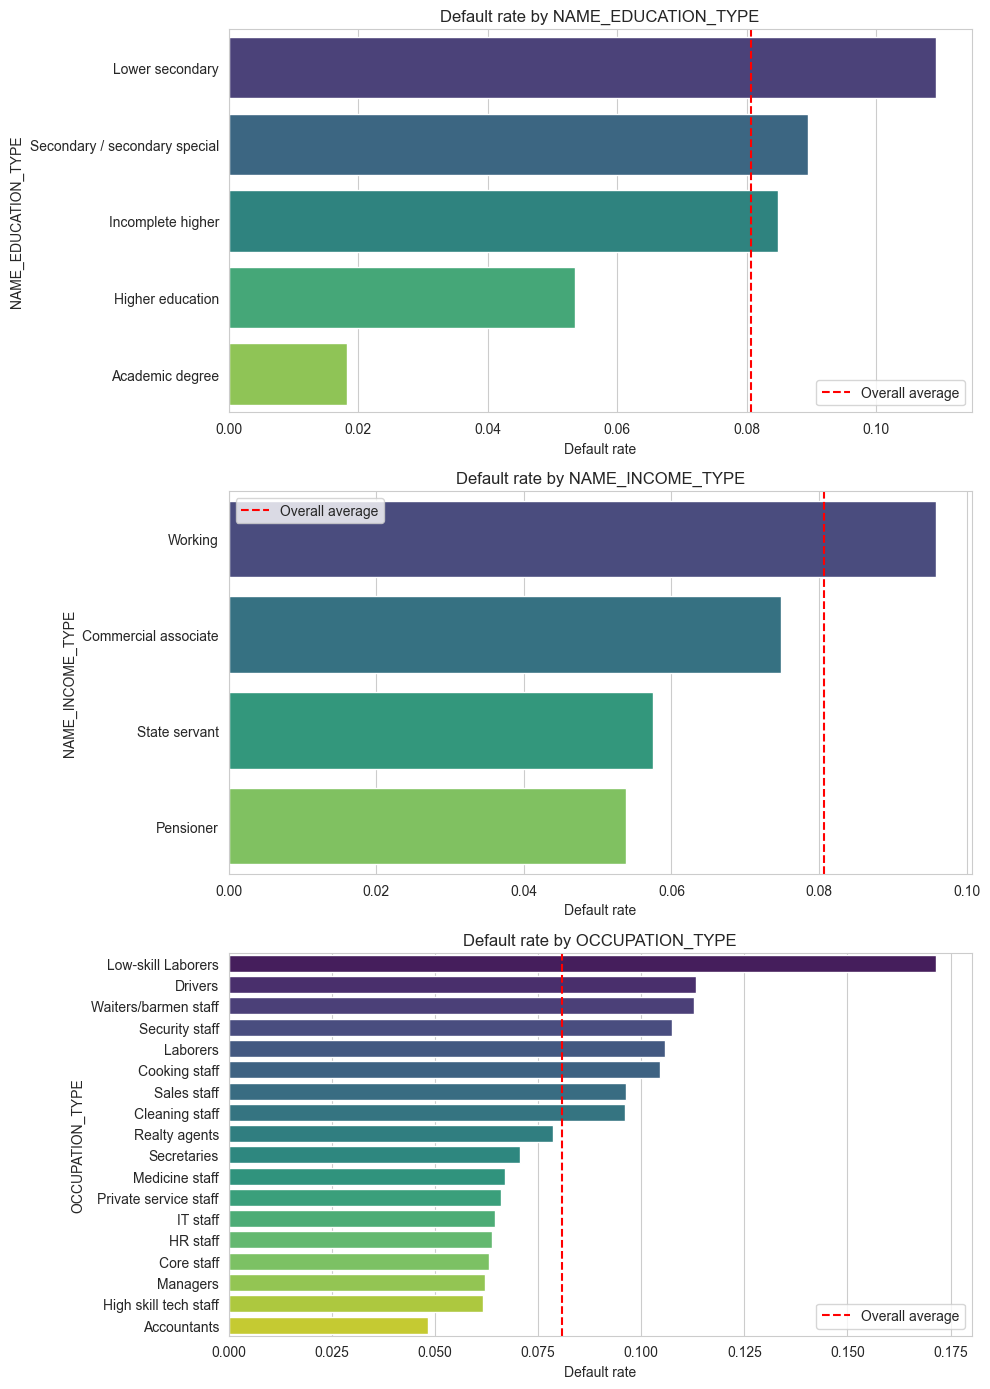

In [33]:
categorical_cols = ["NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE", "OCCUPATION_TYPE"]

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 14))

for ax, col in zip(axes, categorical_cols):
    rate_by_cat = df.groupby(col)["TARGET"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    rate_by_cat = rate_by_cat[rate_by_cat["count"] >= 100]  # drop categories with too few samples to be reliable

    sns.barplot(x=rate_by_cat["mean"].values, y=rate_by_cat.index, ax=ax,
                hue=rate_by_cat.index, palette="viridis", legend=False)
    ax.axvline(df["TARGET"].mean(), color="red", linestyle="--", label="Overall average")
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("Default rate")
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
for col in categorical_cols:
    rate_by_cat = df.groupby(col)["TARGET"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    rate_by_cat = rate_by_cat[rate_by_cat["count"] >= 100]
    spread = rate_by_cat["mean"].max() - rate_by_cat["mean"].min()
    print(f"{col}: spread between highest and lowest default rate = {spread:.1%}")


NAME_EDUCATION_TYPE: spread between highest and lowest default rate = 9.1%
NAME_INCOME_TYPE: spread between highest and lowest default rate = 4.2%
OCCUPATION_TYPE: spread between highest and lowest default rate = 12.3%


## 8. Summary and next steps

- `SK_ID_CURR` is unique: **YES** (307,511 rows, 307,511 unique IDs) — safe to merge on later.
- Target is heavily imbalanced: **91.9% (0) vs. 8.07% (1)** — more imbalanced than the v1 Taiwan dataset (~78/22).
- 67 of 122 columns have missing values. The top ones (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, building/apartment details) are missing ~66-70% — expected, since most applicants don't report detailed housing information. Not a data-quality issue.
- Key financial variables (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`) show only **weak separation** between TARGET=0 and TARGET=1.
- Categorical variables show **much stronger signal** than raw financial values:
  - `NAME_EDUCATION_TYPE`: ~9.2 pp spread (Lower secondary ~11% vs. Academic degree ~1.8%)
  - `NAME_INCOME_TYPE`: ~4.1 pp spread (Working ~9.5% vs. Pensioner ~5.4%)
  - `OCCUPATION_TYPE`: ~12.2 pp spread, the strongest of the three (Low-skill Laborers ~17%, more than double the overall average, vs. Accountants ~4.8%)
- `DAYS_EMPLOYED` placeholder (365243, meaning unemployed/retired) affects a meaningful share of rows — handled correctly by converting to NaN before analysis.

**Next step:** explore how to connect this table with `bureau.csv` (credit history at other institutions) using `SK_ID_CURR`, since that's where genuinely behavioral, temporal signal is expected to appear — the categorical variables here are demographic/occupational, useful but static, not behavioral.
